# Exploratory Data Analysis & Intro


# Goal 

1. Investigate top-paying roles and skills in the data science industry/
2. Use Python to explore a real-live dataset on job postings. 
3. For job-seekers: use these insights to help find the best job opportunities.

# Final Deliverables:

1. Create Jupyter Notebooks (showcasing core skills in Python)
2. Create a summary page (via README.md) capturing your findings.
3. Share this project via GitHub and LinkedIn. 

Questions to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on Data Analyst roles in Canada

# Exploratory Data Analysis for all Data Roles

### Roles to Explore

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Canada Data Analyst Roles

In [10]:
df_DA_Canada = df[(df['job_country'] == 'Canada') &(df['job_title_short'] == 'Data Analyst')]
df_DA_Canada['job_location']

81         Regina, SK, Canada
118                    Canada
225                  Anywhere
638                  Anywhere
867                  Anywhere
                 ...         
782276                 Canada
782746    Halifax, NS, Canada
783072                 Canada
783652                 Canada
784498                 Canada
Name: job_location, Length: 2365, dtype: object

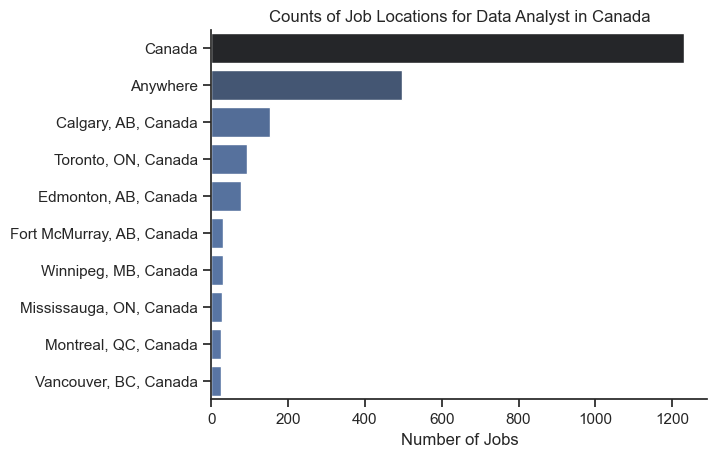

In [15]:
df_plot = df_DA_Canada['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Canada')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

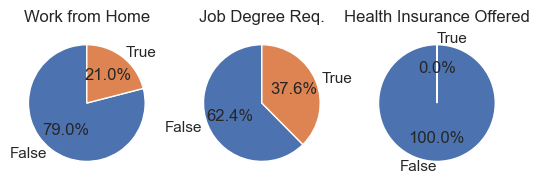

In [16]:
fig, ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    #print(i,column, title)
    ax[i].pie(df_DA_Canada[column].value_counts(),startangle=90,autopct='%1.1f%%',labels=['False','True'])
    ax[i].set_title(title)

plt.show()

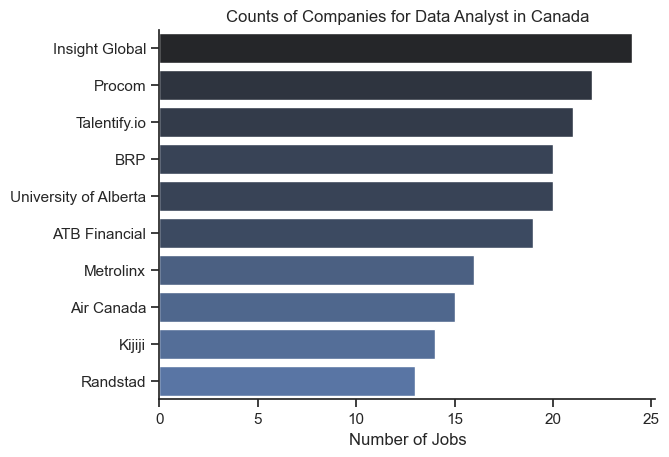

In [18]:
df_plot = df_DA_Canada['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Canada')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()